# Dijkstra's Algorithm — wave expansion visualization

Notebook accompanying the subsection **Dijkstra's Algorithm** from the chapter *LLMs as Planners: Methods, Capabilities, and Limitations*.

## Concrete task: from home to school across the bridge

The 25×25 grid is a map of a certain **neighborhood** (1 square ≈ 100 m). The protagonist is a student walking **from home to school**:

- **Start (3, 3)** — *home* (green circle on the plot).
- **Goal (21, 21)** — *school* (white star), on the **other side of the river**.
- **Vertical wall (column 12)** — *river* cutting through the neighborhood; it cannot be waded across.
- **Break in the river (rows 10–14)** — the only **bridge**; every route must cross it.
- **Two short obstacles** — *housing blocks / park*, which cannot be crossed.
- **Step cost = 1** — we walk, every square takes the same effort (time).

**What we aim for:** find the **shortest** walking route home → school (across the bridge).

**What we compare:** two algorithms that will find the **same** optimal route, but *search for it in completely different ways*:
- **Dijkstra** — *does not know* where the school is; explores the surroundings **evenly in all directions** ($h = 0$).
- **A\*** — *knows the address* of the school (its coordinates) and **directs** the search towards it (Manhattan heuristic).

**Where the differences come from** — this is explained by the analogy below, and confirmed by the metrics at the end.


## Intuition: spilling water and a tilted table

**Dijkstra = water on a flat table.** At *home* you pour a bucket of water on the flat map of the neighborhood. The wave spreads **evenly in all directions**; the moment it first reaches a given place is its shortest distance from home, or $g(v)$. The water flows around *housing blocks* and squeezes through the *bridge* — but it spills evenly everywhere because it **does not know where the school is** (panel b: a large "splatter").

**A\* = the same table, but tilted towards the school.** Since we know the **address** of the school (its coordinates), we tilt the entire terrain so that the **school is the lowest point**. The water still obeys physics, but **flows preferentially towards the goal** (panel c: a narrow corridor). The amount of tilt at point $x$ is the heuristic $h(x)$.

**How do we know which way to tilt?** We know **WHERE** the school is, even if we do not know **HOW** to get there. We calculate the "downhill" direction trivially — by subtracting the coordinates (the `h(node)` function below looks *exclusively* at `goal` and never at the obstacle map). It's like a **compass / GPS to a known address**: at every corner you know the school is "2 km northeast in a straight line", even if you don't yet know which streets to take to get there.

**The catch (admissibility).** The tilt is a "straight line" guess that **ignores the river and buildings**. When the bridge is off to the side, the A\* water momentarily backs up and spreads (the heuristic was too optimistic) — but as long as we **do not tilt steeper than the actual distance** ($h(x) \le h^*(x)$), we will never miss the truly shortest path. That is why A\* returns the **same** route as Dijkstra, only it finds it more cheaply.

> If the task **did not provide geometry** (abstract graph without coordinates), we would have no way to guess the direction → $h = 0$ → A\* degenerates to Dijkstra. The tilt comes from the knowledge of the goal's location, not from thin air.


In [1]:
import numpy as np
import heapq
import os
import matplotlib.pyplot as plt

# --- Scene: student walks from HOME to SCHOOL across the only BRIDGE on the river ---
GRID = 25          # neighborhood map 25 x 25 (1 square ~ 100 m)
START = (3, 3)     # HOME (row, column)
GOAL = (21, 21)    # SCHOOL, on the other side of the river

# 0 = free space (street), 1 = obstacle
obstacles = np.zeros((GRID, GRID), dtype=int)

# RIVER: vertical wall in column 12. The only BRIDGE is the gap in rows 10-14 --
# every route home -> school must pass through it.
for r in range(GRID):
    if not (10 <= r <= 14):
        obstacles[r, 12] = 1

# Housing blocks / park -- they cannot be crossed (the wave must flow around them).
for c in range(4, 9):
    obstacles[7, c] = 1
for c in range(16, 21):
    obstacles[17, c] = 1

print('Grid ready:', obstacles.shape, '| obstacles:', int(obstacles.sum()))
print('Scene: HOME', START, '-> SCHOOL', GOAL, '| river: column 12, bridge: rows 10-14')


Grid ready: (25, 25) | obstacles: 30
Scene: HOME (3, 3) -> SCHOOL (21, 21) | river: column 12, bridge: rows 10-14


## 1. Implementation

A single function implements both algorithms: for `use_heuristic=False` it's Dijkstra, for `True` — A\*. We record the **expansion order** of each node to later visualize the growing frontier.

Notice `h(node)` — this is the "tilt of the table" towards the school. It looks **exclusively at the goal coordinates** (`goal`), and **never** at `grid`/obstacles: this is the formal equivalent of the sentence "we know WHERE the school is, we do not know HOW to get there yet". For Dijkstra, the tilt is zero ($h = 0$) — the table is flat.


In [2]:
def search(grid, start, goal, use_heuristic):
    """Unified implementation of Dijkstra (use_heuristic=False) and A* (=True).

    4-connected grid, cost of each step = 1. Returns:
      g      - matrix of cost-to-come g(v) (inf where unreached),
      order  - expansion order (iteration number, -1 = unexpanded),
      path   - optimal path start->goal,
      n_expanded - number of expanded (closed) nodes.
    """
    n_rows, n_cols = grid.shape

    def h(node):  # Heuristic h(x): Manhattan (A*) or 0 (Dijkstra). Admissibility condition: h(x) <= h*(x)
        if not use_heuristic:
            return 0.0
        return abs(node[0] - goal[0]) + abs(node[1] - goal[1])

    g = np.full(grid.shape, np.inf)
    order = np.full(grid.shape, -1, dtype=int)
    parent = {start: None}
    closed = np.zeros(grid.shape, dtype=bool)

    g[start] = 0.0
    open_heap = [(h(start), 0.0, start)]
    n_expanded = 0

    while open_heap:
        # STEP 1 (Principle of operation): get u = argmin_v f(v); here f = g + h (for Dijkstra h=0, so f=g)
        _, gc, u = heapq.heappop(open_heap)
        if closed[u]:
            continue
        closed[u] = True            # STEP 3: close u (move to the set of visited S)
        order[u] = n_expanded
        n_expanded += 1
        if u == goal:
            break
        r, c = u
        for dr, dc in ((-1, 0), (1, 0), (0, -1), (0, 1)):
            nr, nc = r + dr, c + dc
            if 0 <= nr < n_rows and 0 <= nc < n_cols and grid[nr, nc] == 0:
                nb = (nr, nc)
                ng = gc + 1.0
                if ng < g[nb]:      # STEP 2: edge relaxation -- g(v) <- g(u) + w(u,v), here w = 1
                    g[nb] = ng
                    parent[nb] = u
                    # Priority in queue = evaluation function f(x) = g(x) + h(x)   [A* formula: f = g + h]
                    heapq.heappush(open_heap, (ng + h(nb), ng, nb))

    path = []
    if goal in parent:
        cur = goal
        while cur is not None:
            path.append(cur)
            cur = parent[cur]
        path.reverse()
    return g, order, path, n_expanded


## Step-by-step trace (Dijkstra and A\*)

Before we run the full pass and metrics, let's trace the **first iterations** of both algorithms — exactly according to the three steps from the *"Principle of operation"* list in the chapter:

1. **STEP 1** — get vertex $u = \arg\min f$ from the queue (for Dijkstra $f = g$, since $h = 0$; for A\* $f = g + h$),
2. **STEP 2** — edge **relaxation**: for each neighbor check if going through $u$ is cheaper, and if so — update $g$,
3. **STEP 3** — **close** $u$ (move to set $S$); its cost will not change anymore.

The `trace_search` function below is **standalone** (it does not depend on `search`) and is intended strictly for didactic purposes — it prints *what* happens in each iteration. Compare the two outputs: Dijkstra extracts vertices symmetrically around the start (all with the same $g$), while A\*, thanks to the heuristic $h$, prefers those with a smaller $f$, i.e., closer to the goal — the exact same behavior that later manifests on the plot as a narrow corridor.


In [3]:
# --- Step-by-step trace: the same 3 steps as in the "Principle of operation" list ---
# STEP 1: get u = argmin f  (for Dijkstra f = g, because h = 0)
# STEP 2: edge relaxation to neighbors of u
# STEP 3: close u (move to set S)
def trace_search(grid, start, goal, use_heuristic, max_iter=6):
    """Prints the execution of the first `max_iter` iterations (didactic purpose).

    use_heuristic=False -> Dijkstra, True -> A*. Shows which node
    is extracted from the queue, which edges are relaxed and when
    a node is closed. Standalone - does not depend on `search`.
    """
    n_rows, n_cols = grid.shape

    def h(node):
        if not use_heuristic:
            return 0.0
        return abs(node[0] - goal[0]) + abs(node[1] - goal[1])

    g = {start: 0.0}
    closed = set()
    open_heap = [(h(start), 0.0, start)]
    name = 'A*' if use_heuristic else 'Dijkstra'
    print(f'=== {name}: first {max_iter} iterations (start={start} -> goal={goal}) ===')

    it = 0
    while open_heap and it < max_iter:
        f_u, g_u, u = heapq.heappop(open_heap)
        if u in closed:
            continue
        it += 1
        if use_heuristic:
            print(f'[iter {it}] STEP 1: extract u={u}  g={g_u:.0f}  h={h(u):.0f}  f={f_u:.0f}')
        else:
            print(f'[iter {it}] STEP 1: extract u={u}  g={g_u:.0f}')
        closed.add(u)
        if u == goal:
            print('         goal reached -> end')
            break
        r, c = u
        for dr, dc in ((-1, 0), (1, 0), (0, -1), (0, 1)):
            nr, nc = r + dr, c + dc
            if 0 <= nr < n_rows and 0 <= nc < n_cols and grid[nr, nc] == 0:
                nb = (nr, nc)
                ng = g_u + 1.0
                old = g.get(nb, float('inf'))
                if ng < old:
                    g[nb] = ng
                    heapq.heappush(open_heap, (ng + h(nb), ng, nb))
                    old_txt = 'inf' if old == float('inf') else f'{old:.0f}'
                    if use_heuristic:
                        print(f'         STEP 2: relax {nb}: g {old_txt} -> {ng:.0f}  (f={ng + h(nb):.0f})')
                    else:
                        print(f'         STEP 2: relax {nb}: g {old_txt} -> {ng:.0f}')
        print(f'         STEP 3: close u={u} (add to set S)')

    print(f'(showing {it} iterations; full run computed by search function above)\n')


trace_search(obstacles, START, GOAL, use_heuristic=False)  # Dijkstra
trace_search(obstacles, START, GOAL, use_heuristic=True)   # A*


=== Dijkstra: first 6 iterations (start=(3, 3) -> goal=(21, 21)) ===
[iter 1] STEP 1: extract u=(3, 3)  g=0
         STEP 2: relax (2, 3): g inf -> 1
         STEP 2: relax (4, 3): g inf -> 1
         STEP 2: relax (3, 2): g inf -> 1
         STEP 2: relax (3, 4): g inf -> 1
         STEP 3: close u=(3, 3) (add to set S)
[iter 2] STEP 1: extract u=(2, 3)  g=1
         STEP 2: relax (1, 3): g inf -> 2
         STEP 2: relax (2, 2): g inf -> 2
         STEP 2: relax (2, 4): g inf -> 2
         STEP 3: close u=(2, 3) (add to set S)
[iter 3] STEP 1: extract u=(3, 2)  g=1
         STEP 2: relax (4, 2): g inf -> 2
         STEP 2: relax (3, 1): g inf -> 2
         STEP 3: close u=(3, 2) (add to set S)
[iter 4] STEP 1: extract u=(3, 4)  g=1
         STEP 2: relax (4, 4): g inf -> 2
         STEP 2: relax (3, 5): g inf -> 2
         STEP 3: close u=(3, 4) (add to set S)
[iter 5] STEP 1: extract u=(4, 3)  g=1
         STEP 2: relax (5, 3): g inf -> 2
         STEP 3: close u=(4, 3) (add to set 

## 2. Execution and metrics

In [4]:
g_dij, order_dij, path_dij, exp_dij = search(obstacles, START, GOAL, use_heuristic=False)
g_ast, order_ast, path_ast, exp_ast = search(obstacles, START, GOAL, use_heuristic=True)

print(f'Dijkstra: path length = {len(path_dij)} nodes, cost = {g_dij[GOAL]:.0f}, '
      f'expanded nodes = {exp_dij}')
print(f'A*      : path length = {len(path_ast)} nodes, cost = {g_ast[GOAL]:.0f}, '
      f'expanded nodes = {exp_ast}')
print(f'A* expanded {100 * (1 - exp_ast / exp_dij):.0f}% fewer nodes for the same '
      f'optimal path (cost {g_dij[GOAL]:.0f}).')
print('Interpretation: both paths go through the same BRIDGE. Dijkstra floods the HOME area '
      'evenly; A* heads toward SCHOOL -> same path, much less work.')


Dijkstra: path length = 37 nodes, cost = 36, expanded nodes = 568
A*      : path length = 37 nodes, cost = 36, expanded nodes = 274
A* expanded 52% fewer nodes for the same optimal path (cost 36).
Interpretation: both paths go through the same BRIDGE. Dijkstra floods the HOME area evenly; A* heads toward SCHOOL -> same path, much less work.


## 3. Visualization

The figure is saved to `../figures/dijkstra_wave.pdf` and inserted into the chapter.
- **(a)** cost-to-come map $g(v)$ — the concentric "rings" are precisely Dijkstra's *wave*;
- **(b)** Dijkstra expansion order — a large, round blob growing in all directions;
- **(c)** A\* expansion order — a narrow corridor directed towards the goal.

Saved: chapter_5/figures/dijkstra_wave.{pdf,png}


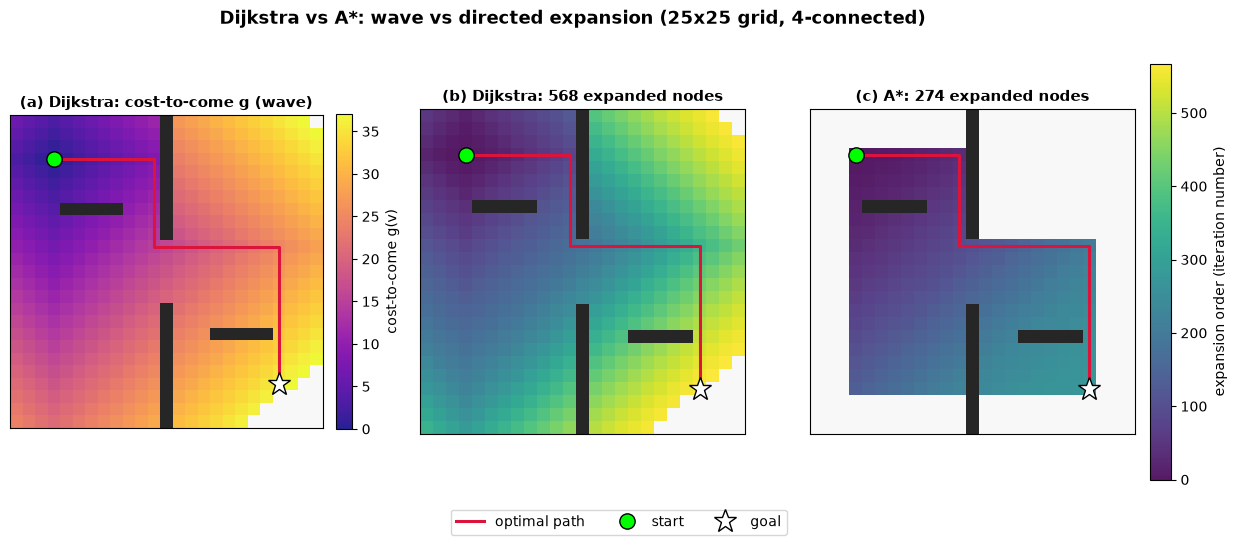

In [5]:
def _draw_background(ax):
    """Draws the background: free cells (light) and obstacles (dark)."""
    ax.imshow(np.where(obstacles == 1, 0.15, 0.97), cmap='gray',
              vmin=0, vmax=1, origin='upper')


def _markers(ax):
    ax.plot(START[1], START[0], 'o', color='lime', markersize=11,
            markeredgecolor='black', label='start')
    ax.plot(GOAL[1], GOAL[0], '*', color='white', markersize=17,
            markeredgecolor='black', label='goal')
    ax.set_xticks([])
    ax.set_yticks([])


def plot_cost(ax, g_grid, path, title):
    _draw_background(ax)
    im = ax.imshow(np.ma.masked_invalid(g_grid), cmap='plasma',
                   origin='upper', alpha=0.9)
    xs = [p[1] for p in path]
    ys = [p[0] for p in path]
    ax.plot(xs, ys, color='crimson', linewidth=2.2, label='optimal path')
    _markers(ax)
    ax.set_title(title, fontsize=11, fontweight='bold')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='cost-to-come g(v)')


def plot_expansion(ax, order_grid, path, title, vmax):
    _draw_background(ax)
    im = ax.imshow(np.ma.masked_where(order_grid < 0, order_grid),
                   cmap='viridis', origin='upper', alpha=0.9, vmin=0, vmax=vmax)
    xs = [p[1] for p in path]
    ys = [p[0] for p in path]
    ax.plot(xs, ys, color='crimson', linewidth=2.2, label='optimal path')
    _markers(ax)
    ax.set_title(title, fontsize=11, fontweight='bold')
    return im


vmax = max(exp_dij, exp_ast) - 1
fig, axes = plt.subplots(1, 3, figsize=(15, 5.4))

plot_cost(axes[0], g_dij, path_dij, '(a) Dijkstra: cost-to-come g (wave)')
plot_expansion(axes[1], order_dij, path_dij,
                f'(b) Dijkstra: {exp_dij} expanded nodes', vmax)
im = plot_expansion(axes[2], order_ast, path_ast,
                     f'(c) A*: {exp_ast} expanded nodes', vmax)

cbar = fig.colorbar(im, ax=[axes[1], axes[2]], fraction=0.03, pad=0.02)
cbar.set_label('expansion order (iteration number)')

fig.suptitle('Dijkstra vs A*: wave vs directed expansion (25x25 grid, 4-connected)',
             fontsize=13, fontweight='bold')

handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=10)

os.makedirs('../figures', exist_ok=True)
fig.savefig('../figures/dijkstra_wave.pdf', bbox_inches='tight')
fig.savefig('../figures/dijkstra_wave.png', dpi=150, bbox_inches='tight')
print('Saved: chapter_5/figures/dijkstra_wave.{pdf,png}')
plt.show()

## 4. Conclusions

- Dijkstra is **optimal and complete**, but *undirected*: without knowledge of the school's location, it expands nodes evenly in all directions (panel b) — *water on a flat table*.
- A\* maintains optimality (an admissible heuristic does not overestimate the cost), and at the same time **drastically reduces the number of expanded nodes** (panel c) — *table tilted towards the known coordinates of the school*.
- **Where the differences come from:** both methods pass through **the same bridge** and return **the same** optimal route (cost 36); they differ solely in the *search method* — Dijkstra "floods" the home area, A\* "flows" toward the school. The heuristic does not change the result, but it restricts the search area. If there was no geometry (no goal coordinates), $h = 0$ and A\* would become Dijkstra.

Interactive, reference visualizations of these algorithms: A. Patel, *Introduction to the A\* Algorithm* (Red Blob Games) and S. Russell, P. Norvig, *Artificial Intelligence: A Modern Approach* (chapter 3, search contours).
